# Exploratory Data Analysis (EDA) on Katekese Dataset

This notebook analyzes the JSONL datasets located in `data/final` to understand document length distributions and text properties before embedding and RAG.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_theme(style="whitegrid")
DATA_DIR = "../data/final"

## 1. Load Data
We will load all `.jsonl` files and extract their lengths (character and word count).

In [2]:
records = []

for filename in os.listdir(DATA_DIR):
    if filename.endswith(".jsonl"):
        filepath = os.path.join(DATA_DIR, filename)
        source_name = filename.replace("_final.jsonl", "")
        
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                data = json.loads(line)
                
                # Using multiple common keys
                text = data.get("text", "") or data.get("content", "") or data.get("isi", "")
                
                records.append({
                    "source": source_name,
                    "char_count": len(text),
                    "word_count": len(text.split())
                })

df = pd.DataFrame(records)
print(f"Total documents: {len(df)}")
df.head()

Total documents: 36196


,source,char_count,word_count
0,pdf_eBoook-DG-42-RERUM-NOVARUM,176,26
1,pdf_eBoook-DG-42-RERUM-NOVARUM,187,30
2,pdf_eBoook-DG-42-RERUM-NOVARUM,1205,164
3,pdf_eBoook-DG-42-RERUM-NOVARUM,811,92
4,pdf_eBoook-DG-42-RERUM-NOVARUM,8,3


## 2. Basic Statistics

In [3]:
df.groupby("source").agg(
    count=("word_count", "count"),
    avg_words=("word_count", "mean"),
    max_words=("word_count", "max"),
    min_words=("word_count", "min")
).reset_index().sort_values("count", ascending=False)

,source,count,avg_words,max_words,min_words
0,alkitab,29436,21.219935,139,1
6,khk,1752,57.691210,308,7
13,papal_encyclicals,1407,9094.685146,56074,12
4,katekismus,999,79.753754,308,11
7,kkgk,598,77.302676,308,11
18,pdf_Seri-Dokumen-Gerejawi-No-100-AMORIS-LAETIT...,195,286.543590,345,48
27,pdf_Seri-Dokumen-Gerejawi-No-94-EVANGELII-GAUD...,184,268.081522,348,52
25,pdf_Seri-Dokumen-Gerejawi-No-19-GAUDIUM-ET-SPES,146,229.726027,388,19
21,pdf_Seri-Dokumen-Gerejawi-No-109-CHRISTUS-VIVIT-3,130,267.269231,326,5
23,pdf_Seri-Dokumen-Gerejawi-No-116-VERITATIS-GAU...,118,196.313559,280,13


## 3. Distribution of Word Counts
Let's visualize the distribution of word counts to determine the ideal chunk size for the embeddings.

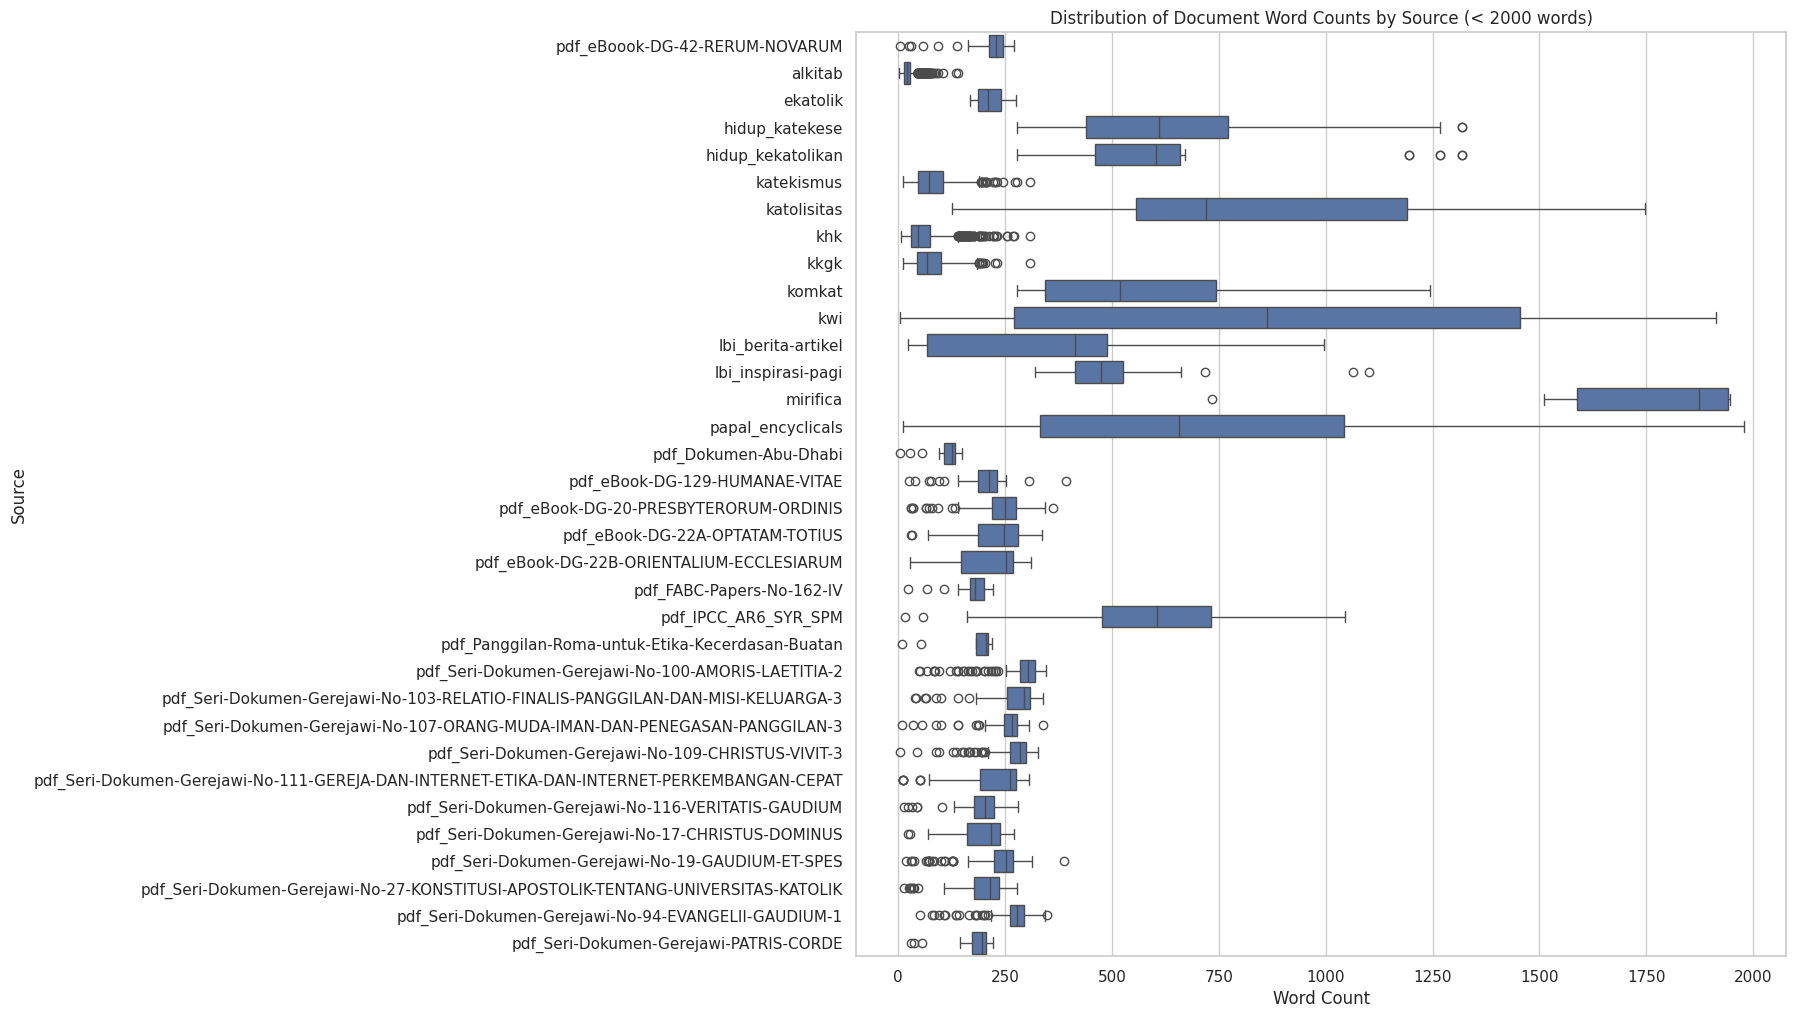

In [4]:
plt.figure(figsize=(12, 12))
# Using horizontal boxplot to avoid visual overlap of many sources
sns.boxplot(data=df[df["word_count"] < 2000], x="word_count", y="source")
plt.title("Distribution of Document Word Counts by Source (< 2000 words)")
plt.xlabel("Word Count")
plt.ylabel("Source")
plt.show()